# Ad-hoc access to level1 image data

Notebook demostrating ad-hoc access to level1 image data.

Author: Rodrigo Ordonez-Hurtado (rodrigo.ordonez.hurtado@ibm.com)


In [13]:
import requests
import s3fs
import zarr
import zarr.storage
import xarray as xr
from matplotlib import pyplot as plt


In [27]:
def open_image_dataset(store, group_name):
    return xr.open_zarr(store=store, group=group_name)


In [2]:
shot_data = requests.get("https://mastapp.site/json/shots/30421").json()

fs = s3fs.S3FileSystem(
    anon=True,
    endpoint_url=shot_data['endpoint_url'],
    asynchronous=True
)

store = zarr.storage.FsspecStore(
    fs=fs,
    read_only=True,
    path=shot_data['url'].split("s3:/")[1]  # '/mast/level1/shots/30421.zarr'
)

group = zarr.open_group(store=store, mode="r")
group.tree()

/
├── abm
│   ├── calib_shot () int16
│   ├── channel_status (32,) float32
│   ├── channel_type (32,) float32
│   ├── chord (11,) float32
│   ├── dim_0 (32,) float32
│   ├── gain (32,) float32
│   ├── i-bol (7500, 32) float32
│   ├── km (32,) float32
│   ├── passnumber () float32
│   ├── phi-chords (32,) float32
│   ├── phi-slits (32,) float32
│   ├── prad_pol (7500,) float32
│   ├── r-chords (32,) float32
│   ├── r-slits (32,) float32
│   ├── r_tco_emis (11,) float32
│   ├── rbm (32,) float32
│   ├── status () float32
│   ├── taum (32,) float32
│   ├── tco_emis (7500, 11) float32
│   ├── time (7500,) float32
│   ├── v-bol (7500, 32) float32
│   ├── version () float32
│   ├── z-chords (32,) float32
│   └── z-slits (32,) float32
├── act
│   ├── _c_plb_cutoff () float32
│   ├── _c_plb_cutofftime () float32
│   ├── _c_plb_cx_counts (160,) float32
│   ├── _c_plb_raw_spectrum (224, 60) float32
│   ├── _c_plb_temperature (160,) float32
│   ├── _c_plb_temperature_error (160,) float32
│   ├── _c_plb_velocity (160,) float32
│   ├── _c_plb_velocity_error (160,) float32
│   ├── c_pla_cutoff () float32
│   ├── c_pla_cutofftime () float32
│   ├── c_pla_cx_counts (160,) float32
│   ├── c_pla_raw_spectrum (224, 60) float32
│   ├── c_pla_temperature (160,) float32
│   ├── c_pla_temperature_error (160,) float32
│   ├── c_pla_velocity (160,) float32
│   ├── c_pla_velocity_error (160,) float32
│   ├── c_ss_cutoff () float32
│   ├── c_ss_cutofftime () float32
│   ├── c_ss_cx_counts (160,) float32
│   ├── c_ss_raw_spectrum (224, 60) float32
│   ├── c_ss_temperature (160,) float32
│   ├── c_ss_temperature_error (160,) float32
│   ├── c_ss_velocity (160,) float32
│   ├── c_ss_velocity_error (160,) float32
│   ├── c_sw_cutoff (6,) float32
│   ├── c_sw_cutofftime (6,) float32
│   ├── c_sw_cx_counts (6, 160) float32
│   ├── c_sw_raw_spectrum (6, 224, 60) float32
│   ├── c_sw_temperature (6, 160) float32
│   ├── c_sw_temperature_error (6, 160) float32
│   ├── c_sw_velocity (6, 160) float32
│   ├── c_sw_velocity_error (6, 160) float32
│   ├── chordno (224,) float32
│   ├── dim_0 (16,) float32
│   ├── lostframes () float32
│   ├── majorradius (160,) float32
│   ├── n_fit (11,) float32
│   ├── n_sw (6,) float32
│   ├── passnumber () int32
│   ├── pixels (60,) float32
│   ├── pla_bgspec (130, 160, 60) float32
│   ├── pla_chisq (130, 224) float32
│   ├── pla_covariance (130, 160, 16) float32
│   ├── pla_cx2bgratio (130, 224) float32
│   ├── pla_cx_counts (130, 160) float32
│   ├── pla_cx_emissivity (130, 160) float32
│   ├── pla_cx_emissivity_error (130, 160) float32
│   ├── pla_cxspec (130, 160, 60) float32
│   ├── pla_fits (130, 160, 60) float32
│   ├── pla_spectra (130, 160, 60) float32
│   ├── pla_temperature (130, 160) float32
│   ├── pla_temperature_error (130, 160) float32
│   ├── pla_velocity (130, 160) float32
│   ├── pla_velocity_error (130, 160) float32
│   ├── radfitc (11,) float32
│   ├── ss_bgspec (130, 160, 60) float32
│   ├── ss_chisq (130, 224) float32
│   ├── ss_covariance (130, 160, 16) float32
│   ├── ss_cx2bgratio (130, 224) float32
│   ├── ss_cx_counts (130, 160) float32
│   ├── ss_cx_emissivity (130, 160) float32
│   ├── ss_cx_emissivity_error (130, 160) float32
│   ├── ss_cxspec (130, 160, 60) float32
│   ├── ss_fits (130, 160, 60) float32
│   ├── ss_spectra (130, 160, 60) float32
│   ├── ss_temperature (130, 160) float32
│   ├── ss_temperature_error (130, 160) float32
│   ├── ss_velocity (130, 160) float32
│   ├── ss_velocity_error (130, 160) float32
│   ├── status () int32
│   ├── sw_bgspec (130, 160, 60) float32
│   ├── sw_chisq (130, 224) float32
│   ├── sw_covariance (130, 160, 16) float32
│   ├── sw_cx2bgratio (130, 224) float32
│   ├── sw_cx_counts (130, 160) float32
│   ├── sw_cx_emissivity (130, 160) float32
│   ├── sw_cx_emissivity_error (130, 160) float32
│   ├── sw_cxspec (130, 160, 60) float32
│   ├── sw_fits (130, 160, 60) float32
│   ├── sw_spectra (130, 160, 60) float32
│   ├── sw_temperature (130, 160) float32
│   ├──

# RBA images

<xarray.Dataset> Size: 315MB
Dimensions:  (time: 450, height: 912, width: 768)
Coordinates:
  * time     (time) float64 4kB 0.000256 0.002256 0.004256 ... 0.6963 0.6983
Dimensions without coordinates: height, width
Data variables:
    data     (time, height, width) uint8 315MB ...
Attributes: (12/48)
    CLASS:           IMAGE
    IMAGE_SUBCLASS:  IMAGE_INDEXED
    IMAGE_VERSION:   1.2
    board_temp:      0.0
    bottom:          1024
    camera:          
    ...              ...
    units:           pixels
    uuid:            f283e185-58a3-54f4-a5f4-a6fef86f9347
    vbin:            0
    version:         -1
    view:            Hl07 floor mount + FFC2 + 25mm lens + CII filter
    width:           768


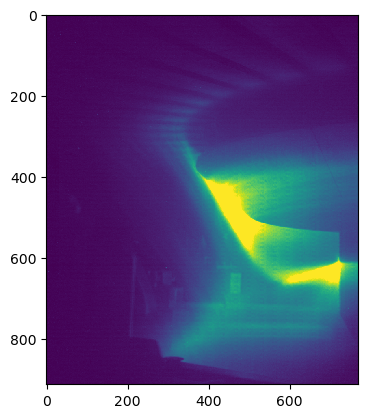

In [35]:
# ├── rba
# │   ├── data (450, 912, 768) uint8
# │   └── time (450,) float64

dataset_rba = open_image_dataset(store, 'rba')
print(dataset_rba)

plt.imshow(dataset_rba.data.values[100], interpolation='nearest')
plt.show()


# RBB Images

<xarray.Dataset> Size: 143MB
Dimensions:  (time: 500, height: 448, width: 640)
Coordinates:
  * time     (time) float64 4kB 1.6e-05 0.002016 0.004016 ... 0.694 0.696 0.698
Dimensions without coordinates: height, width
Data variables:
    data     (time, height, width) uint8 143MB ...
Attributes: (12/48)
    CLASS:           IMAGE
    IMAGE_SUBCLASS:  IMAGE_INDEXED
    IMAGE_VERSION:   1.2
    board_temp:      0.0
    bottom:          680
    camera:          
    ...              ...
    units:           pixels
    uuid:            857f64f0-5329-5fc3-9e70-dafd4a69d4e7
    vbin:            0
    version:         -1
    view:            photron HM10 + Dalpha filter
    width:           640


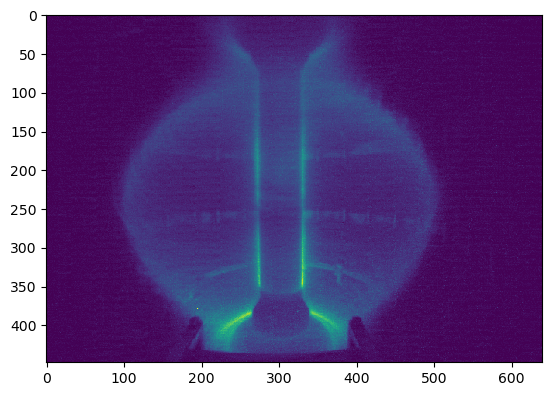

In [34]:
# ├── rbb
# │   ├── data (500, 448, 640) uint8
# │   └── time (500,) float64

dataset_rbb = open_image_dataset(store, 'rbb')
print(dataset_rbb)

plt.imshow(dataset_rbb.data.values[100], interpolation='nearest')
plt.show()


# RBC Images

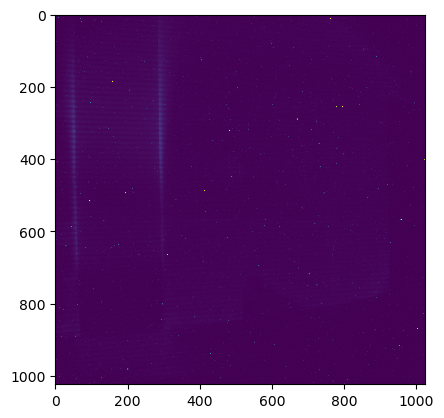

In [38]:
# ├── rbc
# │   ├── data (42, 1024, 1024) uint16
# │   └── time (42,) float64

dataset_rbc = open_image_dataset(store, 'rbc')
dataset_rbc

plt.imshow(dataset_rbc.data.values[10], interpolation='nearest')
plt.show()


# RCO Images

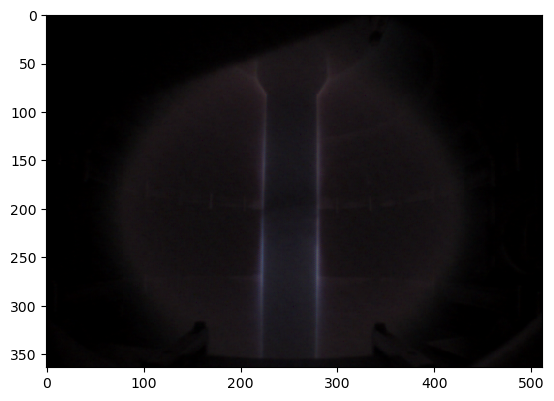

In [39]:
# ├── rco
# │   ├── data (750, 364, 512, 3) uint8
# │   └── time (750,) float64

dataset_rco = open_image_dataset(store, 'rco')
dataset_rco

plt.imshow(dataset_rco.data.values[100], interpolation='nearest')
plt.show()


# RGB Images

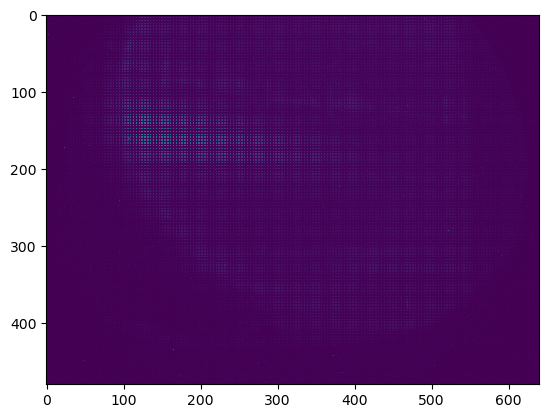

In [40]:
# ├── rgb
# │   ├── data (99, 480, 640) uint16
# │   └── time (99,) float64

dataset_rgb = open_image_dataset(store, 'rgb')
dataset_rgb

plt.imshow(dataset_rgb.data.values[50], interpolation='nearest')
plt.show()


# RGC Images

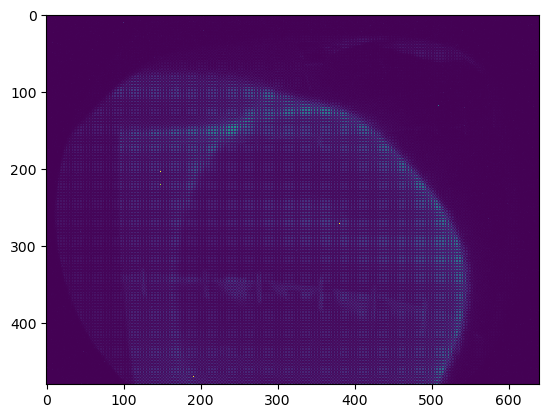

In [41]:
# ├── rgc
# │   ├── data (186, 480, 640) uint16
# │   └── time (186,) float64

dataset_rgc = open_image_dataset(store, 'rgc')
dataset_rgc

plt.imshow(dataset_rgc.data.values[100], interpolation='nearest')
plt.show()
